In [3]:

from langgraph.graph import  StateGraph, START, END
from typing import TypedDict
from dotenv import  load_dotenv
from langgraph.checkpoint.memory import  InMemorySaver
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(model = 'gpt-4o-mini')

In [5]:
# Define the State:

class JokeState(TypedDict):

    topic: str 
    joke: str
    explaination : str

In [18]:
def generate_joke(state: JokeState):

    prompt = f"generate the joke on the topic {state['topic']}"

    response = model.invoke(prompt).content

    return {'joke': response}

    

In [19]:
def generate_explaination(state: JokeState):
    prompt = f"write a explaination on the joke - {state['joke']}"

    response = model.invoke(prompt).content

    return {'explaination': response}
    

In [20]:
# Define the StateGraph

graph = StateGraph(JokeState)

# add nodes
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explaination', generate_explaination)

# add edge
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)

# define the checkpointer
checkpointer = InMemorySaver()


# compile the graph
workflow = graph.compile(checkpointer=checkpointer)

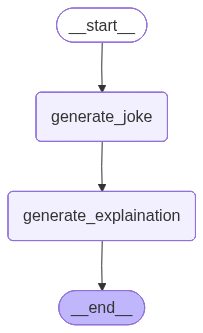

In [21]:

from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [22]:
# exexute the workflow

config1 = {
    'configurable': {"thread_id":"1"}
}

result = workflow.invoke({'topic':'pizza'},config = config1)
print(result)

{'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make ends "meat"! 🍕😄', 'explaination': 'The joke "Why did the pizza maker go broke? Because he just couldn’t make ends \'meat\'!" relies on a clever play on words, specifically a pun involving the phrase "make ends meet."\n\n1. **Phrase Explanation**: The phrase "make ends meet" is an idiomatic expression that means to manage one\'s financial resources so that expenses do not exceed income. It\'s often used in contexts where someone is struggling to cover their basic living expenses.\n\n2. **Pun Element**: The humor comes from the substitution of the word "meet" with "meat," which is a common ingredient in pizza. By using "meat," the joke creates a double meaning. On one hand, the pizza maker is having financial difficulties (unable to make ends meet), and on the other hand, it humorously suggests that he can\'t produce enough "meat" (perhaps indicating a lack of customers wanting meat toppings or

In [25]:
# fetch the state of of my current workflow

workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make ends "meat"! 🍕😄', 'explaination': 'The joke "Why did the pizza maker go broke? Because he just couldn’t make ends \'meat\'!" relies on a clever play on words, specifically a pun involving the phrase "make ends meet."\n\n1. **Phrase Explanation**: The phrase "make ends meet" is an idiomatic expression that means to manage one\'s financial resources so that expenses do not exceed income. It\'s often used in contexts where someone is struggling to cover their basic living expenses.\n\n2. **Pun Element**: The humor comes from the substitution of the word "meet" with "meat," which is a common ingredient in pizza. By using "meat," the joke creates a double meaning. On one hand, the pizza maker is having financial difficulties (unable to make ends meet), and on the other hand, it humorously suggests that he can\'t produce enough "meat" (perhaps indicating a lack of customers wan

In [27]:
# to get all the state:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make ends "meat"! 🍕😄', 'explaination': 'The joke "Why did the pizza maker go broke? Because he just couldn’t make ends \'meat\'!" relies on a clever play on words, specifically a pun involving the phrase "make ends meet."\n\n1. **Phrase Explanation**: The phrase "make ends meet" is an idiomatic expression that means to manage one\'s financial resources so that expenses do not exceed income. It\'s often used in contexts where someone is struggling to cover their basic living expenses.\n\n2. **Pun Element**: The humor comes from the substitution of the word "meet" with "meat," which is a common ingredient in pizza. By using "meat," the joke creates a double meaning. On one hand, the pizza maker is having financial difficulties (unable to make ends meet), and on the other hand, it humorously suggests that he can\'t produce enough "meat" (perhaps indicating a lack of customers wa

In [28]:
# 2 example:

config2 = {
    'configurable': {"thread_id":"2"}
}

result = workflow.invoke({'topic':'pasta'},config = config2)
print(result)

{'topic': 'pasta', 'joke': "Why did the pasta break up with the tomato?\n\nBecause it couldn't handle the sauce of their relationship! 🍝❤️", 'explaination': 'This joke plays on a pun involving the words "sauce" and "source," as well as the dynamics of a romantic relationship. Here\'s a breakdown of the humor:\n\n1. **Characterization of Food**: The joke anthropomorphizes pasta and tomato, treating them as if they were in a romantic relationship. This personification adds a layer of whimsy since both items are typically associated with cooking and are inanimate objects.\n\n2. **Pun on "Sauce" and "Source"**: The punchline hinges on the double meaning of "sauce." In the context of cooking, sauce refers to the rich, flavorful liquid often used in pasta dishes, primarily made with tomatoes. However, "sauce" can also be interpreted as a play on "sauce" as a metaphor for the emotional weight or intensity ("the source") of their relationship. The pasta, in this context, is saying it couldn\'t

In [29]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': "Why did the pasta break up with the tomato?\n\nBecause it couldn't handle the sauce of their relationship! 🍝❤️", 'explaination': 'This joke plays on a pun involving the words "sauce" and "source," as well as the dynamics of a romantic relationship. Here\'s a breakdown of the humor:\n\n1. **Characterization of Food**: The joke anthropomorphizes pasta and tomato, treating them as if they were in a romantic relationship. This personification adds a layer of whimsy since both items are typically associated with cooking and are inanimate objects.\n\n2. **Pun on "Sauce" and "Source"**: The punchline hinges on the double meaning of "sauce." In the context of cooking, sauce refers to the rich, flavorful liquid often used in pasta dishes, primarily made with tomatoes. However, "sauce" can also be interpreted as a play on "sauce" as a metaphor for the emotional weight or intensity ("the source") of their relationship. The pasta, in this context, i

In [30]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': "Why did the pasta break up with the tomato?\n\nBecause it couldn't handle the sauce of their relationship! 🍝❤️", 'explaination': 'This joke plays on a pun involving the words "sauce" and "source," as well as the dynamics of a romantic relationship. Here\'s a breakdown of the humor:\n\n1. **Characterization of Food**: The joke anthropomorphizes pasta and tomato, treating them as if they were in a romantic relationship. This personification adds a layer of whimsy since both items are typically associated with cooking and are inanimate objects.\n\n2. **Pun on "Sauce" and "Source"**: The punchline hinges on the double meaning of "sauce." In the context of cooking, sauce refers to the rich, flavorful liquid often used in pasta dishes, primarily made with tomatoes. However, "sauce" can also be interpreted as a play on "sauce" as a metaphor for the emotional weight or intensity ("the source") of their relationship. The pasta, in this context, 